# Notebook 03 — Alert Policy Selection

**Project:** IntraSight-ESI — Clinical Triage Decision Support  
**Input:** Out-of-fold predictions from NB02, Set A (triage-only strict model)  
**Goal:** Select the optimal alert threshold per ESI category using a pre-declared decision criterion — no post-hoc adjustment after seeing results.

**No new models are trained in this notebook.**

---
### Pre-declared selection criterion
For each ESI, choose the threshold that:
1. Captures at least **25% of serious outcomes** (recall ≥ 0.25) — operational floor
2. Among thresholds meeting criterion 1, **maximizes enrichment** (PPV / base rate)
3. Among ties, choose **lower alert burden**

Rationale: a threshold that achieves very high enrichment but misses 90% of at-risk patients has limited clinical utility. The 25% recall floor ensures the system is operationally relevant, not just a cherry-picker.

---
## Section 0 — Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

BASE_DIR   = Path(r'C:\Users\pablo\OneDrive\Desktop\triagegeist_submission')
NB02_DIR   = BASE_DIR / 'reports' / '02_model_validation'
REPORT_DIR = BASE_DIR / 'reports' / '03_alert_policy'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Setup complete.')


Setup complete.


In [2]:
# Load OOF predictions — Set A only
oof = {}
for esi in [3, 4, 5]:
    df_esi = pd.read_csv(NB02_DIR / f'02_oof_predictions_esi{esi}.csv')
    assert 'oof_score_A' in df_esi.columns, f'ESI {esi}: missing oof_score_A'
    assert 'outcome' in df_esi.columns
    oof[esi] = df_esi
    n_valid = df_esi['oof_score_A'].notna().sum()
    base_rate = df_esi['outcome'].mean()
    print(f'ESI {esi}: N={len(df_esi):,}  valid scores={n_valid:,}  '
          f'base rate={base_rate:.3f}  positives={int(df_esi["outcome"].sum())}')

# Load clinical baselines from NB02
df_baselines = pd.read_csv(NB02_DIR / '02_baselines_clinical_rules.csv')
print(f'\nBaselines loaded: {len(df_baselines)} rows')
print('Score column used: oof_score_A (Set A, triage-only strict — final model)')


ESI 3: N=31,460  valid scores=31,460  base rate=0.135  positives=4244
ESI 4: N=20,182  valid scores=20,182  base rate=0.025  positives=502
ESI 5: N=3,102  valid scores=3,102  base rate=0.035  positives=109

Baselines loaded: 18 rows
Score column used: oof_score_A (Set A, triage-only strict — final model)


---
## Section 1 — Threshold Sweep by ESI

Each threshold is defined as a **percentile of the OOF score distribution** within the ESI group. 'Top 10%' means the 10% of ESI patients with the highest predicted risk scores. This is a relative threshold — it selects a fixed proportion of patients per ESI, not a fixed probability cutoff.

In [3]:
THRESHOLDS_PCT = [3, 5, 10, 15, 20, 25, 30]

def threshold_sweep(df_esi, esi_label):
    """Full sweep of top-N% thresholds for one ESI."""
    scores = df_esi['oof_score_A'].values
    y_true = df_esi['outcome'].values
    valid  = ~np.isnan(scores)
    s_v, y_v = scores[valid], y_true[valid]

    n_total   = valid.sum()
    n_pos     = y_v.sum()
    base_rate = y_v.mean()
    rows = []
    for pct in THRESHOLDS_PCT:
        thresh   = np.percentile(s_v, 100 - pct)
        flagged  = s_v >= thresh
        n_flag   = int(flagged.sum())
        n_out    = int(y_v[flagged].sum())
        ppv      = n_out / n_flag if n_flag > 0 else 0
        enrichm  = ppv / base_rate if base_rate > 0 else 0
        recall   = n_out / n_pos if n_pos > 0 else 0
        rows.append({
            'esi': esi_label, 'threshold_pct': pct,
            'n_alerted': n_flag, 'n_outcomes_captured': n_out,
            'n_outcomes_total': int(n_pos),
            'alert_burden_pct': round(n_flag / n_total * 100, 1),
            'ppv': round(ppv, 4),
            'base_rate': round(base_rate, 4),
            'enrichment': round(enrichm, 3),
            'recall': round(recall, 3),
            'score_cutoff': round(float(thresh), 4),
        })
    return rows

all_rows = []
for esi in [3, 4, 5]:
    all_rows.extend(threshold_sweep(oof[esi], esi))

df_sweep = pd.DataFrame(all_rows)
df_sweep.to_csv(REPORT_DIR / '03_threshold_sweep_by_esi.csv', index=False)

# Print table per ESI
for esi in [3, 4, 5]:
    sub = df_sweep[df_sweep['esi'] == esi]
    br  = sub['base_rate'].iloc[0]
    print(f'ESI {esi}  (base rate: {br:.3f}  total outcomes: {sub["n_outcomes_total"].iloc[0]})')
    print(f'  {"Threshold":<12} {"N alerted":>10} {"Burden%":>8} '
          f'{"PPV":>7} {"Enrichment":>11} {"Recall":>8} {"Outcomes caught"}')
    for _, r in sub.iterrows():
        meets = ' ✓ recall≥0.25' if r['recall'] >= 0.25 else ''
        print(f'  Top {r["threshold_pct"]:>2}%       '
              f'{r["n_alerted"]:>10,} {r["alert_burden_pct"]:>8.1f}% '
              f'{r["ppv"]:>7.3f} {r["enrichment"]:>11.2f}x '
              f'{r["recall"]:>8.3f}  '
              f'{r["n_outcomes_captured"]}/{r["n_outcomes_total"]}{meets}')
    print()


ESI 3  (base rate: 0.135  total outcomes: 4244)
  Threshold     N alerted  Burden%     PPV  Enrichment   Recall Outcomes caught
  Top 3.0%            944.0      3.0%   0.577        4.28x    0.128  545.0/4244.0
  Top 5.0%          1,573.0      5.0%   0.498        3.69x    0.184  783.0/4244.0
  Top 10.0%          3,146.0     10.0%   0.420        3.11x    0.311  1320.0/4244.0 ✓ recall≥0.25
  Top 15.0%          4,719.0     15.0%   0.372        2.75x    0.413  1754.0/4244.0 ✓ recall≥0.25
  Top 20.0%          6,292.0     20.0%   0.332        2.46x    0.492  2090.0/4244.0 ✓ recall≥0.25
  Top 25.0%          7,865.0     25.0%   0.303        2.25x    0.562  2384.0/4244.0 ✓ recall≥0.25
  Top 30.0%          9,438.0     30.0%   0.279        2.07x    0.620  2630.0/4244.0 ✓ recall≥0.25

ESI 4  (base rate: 0.025  total outcomes: 502)
  Threshold     N alerted  Burden%     PPV  Enrichment   Recall Outcomes caught
  Top 3.0%            606.0      3.0%   0.172        6.90x    0.207  104.0/502.0
  Top 5.0

---
## Section 2 — Bootstrap Confidence Intervals

Threshold selection based on point estimates risks choosing by statistical noise. We compute 95% bootstrap CIs (1000 iterations) for PPV, enrichment, and recall at each candidate threshold. ESI 5 CIs will be notably wider given the small N.

In [4]:
N_BOOT = 1000

def bootstrap_threshold_metrics(df_esi, pct, n_boot=N_BOOT, seed=42):
    """Bootstrap CI for PPV, enrichment, recall at a given top-N% threshold."""
    rng    = np.random.RandomState(seed)
    scores = df_esi['oof_score_A'].values
    y_true = df_esi['outcome'].values
    valid  = ~np.isnan(scores)
    s_v, y_v = scores[valid], y_true[valid]

    ppvs, enrichs, recalls = [], [], []
    base_rate_orig = y_v.mean()

    for _ in range(n_boot):
        idx    = rng.choice(len(s_v), len(s_v), replace=True)
        s_b, y_b = s_v[idx], y_v[idx]
        thresh = np.percentile(s_b, 100 - pct)
        flag   = s_b >= thresh
        n_flag = flag.sum()
        n_out  = y_b[flag].sum()
        n_pos  = y_b.sum()
        if n_flag == 0 or n_pos == 0:
            continue
        ppv = n_out / n_flag
        ppvs.append(ppv)
        enrichs.append(ppv / y_b.mean() if y_b.mean() > 0 else 0)
        recalls.append(n_out / n_pos)

    return {
        'ppv_lo': round(np.percentile(ppvs, 2.5), 4),
        'ppv_hi': round(np.percentile(ppvs, 97.5), 4),
        'enrichment_lo': round(np.percentile(enrichs, 2.5), 3),
        'enrichment_hi': round(np.percentile(enrichs, 97.5), 3),
        'recall_lo': round(np.percentile(recalls, 2.5), 3),
        'recall_hi': round(np.percentile(recalls, 97.5), 3),
    }

# Candidate thresholds for CI (5, 10, 15, 20 — practical range)
CI_CANDIDATES = [5, 10, 15, 20]
ci_rows = []

print('Bootstrap 95% CIs (1000 iterations)')
print('Note: wider CIs in ESI 5 expected due to small N.\n')

for esi in [3, 4, 5]:
    print(f'ESI {esi}')
    print(f'  {"Threshold":<10}  {"PPV [95% CI]":<24}  '
          f'{"Enrichment [95% CI]":<26}  {"Recall [95% CI]"}')
    for pct in CI_CANDIDATES:
        pt  = df_sweep[(df_sweep['esi'] == esi) & (df_sweep['threshold_pct'] == pct)].iloc[0]
        ci  = bootstrap_threshold_metrics(oof[esi], pct)
        ppv_str = f'{pt["ppv"]:.3f} [{ci["ppv_lo"]:.3f}–{ci["ppv_hi"]:.3f}]'
        enr_str = f'{pt["enrichment"]:.2f}x [{ci["enrichment_lo"]:.2f}–{ci["enrichment_hi"]:.2f}]'
        rec_str = f'{pt["recall"]:.3f} [{ci["recall_lo"]:.3f}–{ci["recall_hi"]:.3f}]'
        print(f'  Top {pct:>2}%       {ppv_str:<24}  {enr_str:<26}  {rec_str}')
        ci_rows.append({'esi': esi, 'threshold_pct': pct,
                        'ppv': pt['ppv'], **ci,
                        'enrichment': pt['enrichment'], 'recall': pt['recall']})
    print()

df_ci = pd.DataFrame(ci_rows)
df_ci.to_csv(REPORT_DIR / '03_policy_with_ci.csv', index=False)
print('Saved: 03_policy_with_ci.csv')


Bootstrap 95% CIs (1000 iterations)
Note: wider CIs in ESI 5 expected due to small N.

ESI 3
  Threshold   PPV [95% CI]              Enrichment [95% CI]         Recall [95% CI]


  Top  5%       0.498 [0.472–0.523]       3.69x [3.52–3.86]           0.184 [0.176–0.193]


  Top 10%       0.420 [0.402–0.437]       3.11x [3.00–3.23]           0.311 [0.300–0.323]


  Top 15%       0.372 [0.355–0.386]       2.75x [2.67–2.84]           0.413 [0.400–0.426]


  Top 20%       0.332 [0.320–0.344]       2.46x [2.40–2.53]           0.492 [0.479–0.506]

ESI 4
  Threshold   PPV [95% CI]              Enrichment [95% CI]         Recall [95% CI]


...

  Top 10%       0.098 [0.083–0.111]       3.94x [3.48–4.36]           0.394 [0.348–0.436]


  Top 15%       0.078 [0.069–0.088]       3.15x [2.87–3.44]           0.472 [0.431–0.515]


  Top 20%       0.065 [0.058–0.073]       2.63x [2.42–2.85]           0.526 [0.483–0.570]

ESI 5
  Threshold   PPV [95% CI]              Enrichment [95% CI]         Recall [95% CI]
  Top  5%       0.160 [0.108–0.231]       4.56x [3.23–6.13]           0.229 [0.163–0.310]


  Top 10%       0.151 [0.115–0.193]       4.30x [3.51–5.23]           0.431 [0.355–0.527]
  Top 15%       0.116 [0.088–0.146]       3.30x [2.73–3.94]           0.495 [0.410–0.593]


  Top 20%       0.103 [0.079–0.126]       2.93x [2.42–3.33]           0.587 [0.486–0.667]

Saved: 03_policy_with_ci.csv


---
## Section 3 — Policy Selection by ESI

Applying the pre-declared criterion: **minimum burden with recall ≥ 0.25 and maximum enrichment**. Evaluated using OOF point estimates, confirmed by bootstrap CIs above.

In [5]:
final_policy = {}

print('=== POLICY SELECTION — applying pre-declared criterion ===')
print('Criterion: lowest burden achieving recall ≥ 0.25, maximizing enrichment\n')

for esi in [3, 4, 5]:
    sub = df_sweep[df_sweep['esi'] == esi].copy()
    eligible = sub[sub['recall'] >= 0.25].sort_values(
        ['enrichment', 'alert_burden_pct'], ascending=[False, True]
    )

    print(f'ESI {esi}:')
    if len(eligible) == 0:
        print(f'  WARNING: no threshold achieves recall ≥ 0.25.')
        print(f'  ESI {esi} is marked EXPLORATORY — no policy recommended.')
        final_policy[esi] = {
            'esi': esi, 'status': 'exploratory',
            'reason': 'No threshold achieves recall >= 0.25 with stable enrichment',
        }
    else:
        chosen = eligible.iloc[0]
        # Get CI for chosen threshold
        ci_row = df_ci[(df_ci['esi'] == esi) &
                       (df_ci['threshold_pct'] == chosen['threshold_pct'])]
        ci = ci_row.iloc[0] if len(ci_row) > 0 else None

        print(f'  Chosen threshold: Top {int(chosen["threshold_pct"])}%')
        print(f'  Alert burden:     {chosen["alert_burden_pct"]:.1f}% of ESI patients')
        print(f'  PPV:              {chosen["ppv"]:.3f}', end='')
        if ci is not None: print(f' [{ci["ppv_lo"]:.3f}–{ci["ppv_hi"]:.3f}]')
        else: print()
        print(f'  Base rate:        {chosen["base_rate"]:.3f}')
        print(f'  Enrichment:       {chosen["enrichment"]:.2f}x', end='')
        if ci is not None: print(f' [{ci["enrichment_lo"]:.2f}–{ci["enrichment_hi"]:.2f}]')
        else: print()
        print(f'  Recall:           {chosen["recall"]:.3f}', end='')
        if ci is not None: print(f' [{ci["recall_lo"]:.3f}–{ci["recall_hi"]:.3f}]')
        else: print()
        print(f'  Outcomes caught:  {chosen["n_outcomes_captured"]}/{chosen["n_outcomes_total"]}')
        print(f'  Score cutoff:     ≥ {chosen["score_cutoff"]:.4f}')

        final_policy[esi] = {
            'esi': esi, 'status': 'active',
            'threshold_pct': int(chosen['threshold_pct']),
            'score_cutoff': float(chosen['score_cutoff']),
            'alert_burden_pct': float(chosen['alert_burden_pct']),
            'ppv': float(chosen['ppv']),
            'base_rate': float(chosen['base_rate']),
            'enrichment': float(chosen['enrichment']),
            'recall': float(chosen['recall']),
            'n_alerted': int(chosen['n_alerted']),
            'n_outcomes_captured': int(chosen['n_outcomes_captured']),
            'n_outcomes_total': int(chosen['n_outcomes_total']),
            'ppv_ci_lo': float(ci['ppv_lo']) if ci is not None else None,
            'ppv_ci_hi': float(ci['ppv_hi']) if ci is not None else None,
            'enrichment_ci_lo': float(ci['enrichment_lo']) if ci is not None else None,
            'enrichment_ci_hi': float(ci['enrichment_hi']) if ci is not None else None,
            'recall_ci_lo': float(ci['recall_lo']) if ci is not None else None,
            'recall_ci_hi': float(ci['recall_hi']) if ci is not None else None,
        }
    print()

with open(REPORT_DIR / '03_final_policy.json', 'w') as f:
    json.dump(final_policy, f, indent=2)
print('Saved: 03_final_policy.json')


=== POLICY SELECTION — applying pre-declared criterion ===
Criterion: lowest burden achieving recall ≥ 0.25, maximizing enrichment

ESI 3:
  Chosen threshold: Top 10%
  Alert burden:     10.0% of ESI patients
  PPV:              0.420 [0.402–0.437]
  Base rate:        0.135
  Enrichment:       3.11x [3.00–3.23]
  Recall:           0.311 [0.300–0.323]
  Outcomes caught:  1320.0/4244.0
  Score cutoff:     ≥ 0.6991

ESI 4:
  Chosen threshold: Top 5%
  Alert burden:     5.0% of ESI patients
  PPV:              0.144 [0.121–0.165]
  Base rate:        0.025
  Enrichment:       5.77x [5.02–6.57]
  Recall:           0.289 [0.251–0.329]
  Outcomes caught:  145.0/502.0
  Score cutoff:     ≥ 0.5531

ESI 5:
  Chosen threshold: Top 10%
  Alert burden:     10.0% of ESI patients
  PPV:              0.151 [0.115–0.193]
  Base rate:        0.035
  Enrichment:       4.30x [3.51–5.23]
  Recall:           0.431 [0.355–0.527]
  Outcomes caught:  47.0/109.0
  Score cutoff:     ≥ 0.1242

Saved: 03_final_poli

In [6]:
# Summary table of final policy
print('=== FINAL ALERT POLICY SUMMARY ===')
print(f'  {"ESI":<5} {"Threshold":<12} {"Burden%":>8} '
      f'{"PPV [95% CI]":<26} {"Enrichment [95% CI]":<28} {"Recall [95% CI]"}')
print('  ' + '-'*105)
for esi in [3, 4, 5]:
    p = final_policy[esi]
    if p['status'] == 'exploratory':
        print(f'  {esi:<5} EXPLORATORY — no policy recommended (recall < 0.25)')
    else:
        ppv_str = f'{p["ppv"]:.3f} [{p["ppv_ci_lo"]:.3f}–{p["ppv_ci_hi"]:.3f}]'
        enr_str = f'{p["enrichment"]:.2f}x [{p["enrichment_ci_lo"]:.2f}–{p["enrichment_ci_hi"]:.2f}]'
        rec_str = f'{p["recall"]:.3f} [{p["recall_ci_lo"]:.3f}–{p["recall_ci_hi"]:.3f}]'
        print(f'  {esi:<5} Top {p["threshold_pct"]:>2}%       '
              f'{p["alert_burden_pct"]:>7.1f}%  {ppv_str:<26} {enr_str:<28} {rec_str}')


=== FINAL ALERT POLICY SUMMARY ===
  ESI   Threshold     Burden% PPV [95% CI]               Enrichment [95% CI]          Recall [95% CI]
  ---------------------------------------------------------------------------------------------------------
  3     Top 10%          10.0%  0.420 [0.402–0.437]        3.11x [3.00–3.23]            0.311 [0.300–0.323]
  4     Top  5%           5.0%  0.144 [0.121–0.165]        5.77x [5.02–6.57]            0.289 [0.251–0.329]
  5     Top 10%          10.0%  0.151 [0.115–0.193]        4.30x [3.51–5.23]            0.431 [0.355–0.527]


---
## Section 4 — Honest Comparison: Model vs. Clinical Rules

The model is not expected to win on every metric. The key question is whether it provides a better operational trade-off than simple rules a triagist could apply without any software.

**If a simple rule achieves higher enrichment than the model, we say so directly.**  
The model's advantage is recall: it captures more at-risk patients at comparable burden. A rule like *age ≥ 65 AND SpO2 < 94%* achieves very high enrichment but flags very few patients — most at-risk patients in the waiting room do not satisfy that combination.

In [7]:
# Compile comparison table: final model policy vs each baseline rule, per ESI
comparison_rows = []

for esi in [3, 4, 5]:
    # Model row
    p = final_policy[esi]
    if p['status'] == 'active':
        comparison_rows.append({
            'esi': esi,
            'rule_or_model': f'Model Set A (Top {p["threshold_pct"]}%)',
            'n_flagged': p['n_alerted'],
            'alert_burden_pct': p['alert_burden_pct'],
            'ppv': p['ppv'],
            'base_rate': p['base_rate'],
            'enrichment': p['enrichment'],
            'recall': p['recall'],
            'type': 'ML model',
        })
    # Baseline rules
    for _, row in df_baselines[df_baselines['esi'] == esi].iterrows():
        n_total = len(oof[esi])
        n_pos   = int(oof[esi]['outcome'].sum())
        recall_b = row['n_outcomes'] / n_pos if n_pos > 0 else 0
        comparison_rows.append({
            'esi': esi,
            'rule_or_model': row['rule'],
            'n_flagged': row['n_flagged'],
            'alert_burden_pct': row['alert_burden_pct'],
            'ppv': row['ppv'],
            'base_rate': row['base_rate'],
            'enrichment': row['enrichment'],
            'recall': round(recall_b, 3),
            'type': 'clinical rule',
        })

df_comp = pd.DataFrame(comparison_rows)
df_comp.to_csv(REPORT_DIR / '03_model_vs_baselines.csv', index=False)

# Print per ESI
for esi in [3, 4, 5]:
    sub = df_comp[df_comp['esi'] == esi].copy()
    sub = sub.sort_values('enrichment', ascending=False)
    p = final_policy[esi]
    model_enr = p.get('enrichment', 0) if p['status'] == 'active' else 0

    print(f'ESI {esi}  (base rate: {sub["base_rate"].iloc[0]:.3f})')
    print(f'  {"Rule / Model":<38} {"Burden%":>8} {"PPV":>7} '
          f'{"Enrichment":>11} {"Recall":>8} {"Type"}')
    print('  ' + '-'*92)
    for _, r in sub.iterrows():
        wins = ' ← BEATS MODEL' if (r['type'] == 'clinical rule'
                                    and r['enrichment'] > model_enr) else ''
        print(f'  {r["rule_or_model"]:<38} {r["alert_burden_pct"]:>8.1f}% '
              f'{r["ppv"]:>7.3f} {r["enrichment"]:>11.2f}x '
              f'{r["recall"]:>8.3f}  {r["type"]}{wins}')
    print()

print('Saved: 03_model_vs_baselines.csv')
print()
print('Key takeaway:')
print('  The model captures more at-risk patients (higher recall) at comparable burden.')
print('  Where simple rules beat the model in enrichment, they do so at very low recall')
print('  (most at-risk patients in the waiting room do not satisfy those combinations).')


ESI 3  (base rate: 0.135)
  Rule / Model                            Burden%     PPV  Enrichment   Recall Type
  --------------------------------------------------------------------------------------------
  age_65plus AND hypoxemia_flag               2.1%   0.451        3.35x    0.069  clinical rule ← BEATS MODEL
  Model Set A (Top 10%)                      10.0%   0.420        3.11x    0.311  ML model
  hypoxemia_flag                              4.6%   0.315        2.34x    0.107  clinical rule
  age_65plus                                 19.9%   0.284        2.10x    0.419  clinical rule
  age_65plus OR hypoxemia_flag               22.4%   0.275        2.04x    0.457  clinical rule
  comorbidity_count >= 2                     23.4%   0.251        1.86x    0.435  clinical rule
  bp_not_missing                             93.4%   0.139        1.03x    0.960  clinical rule

ESI 4  (base rate: 0.025)
  Rule / Model                            Burden%     PPV  Enrichment   Recall Type
  -

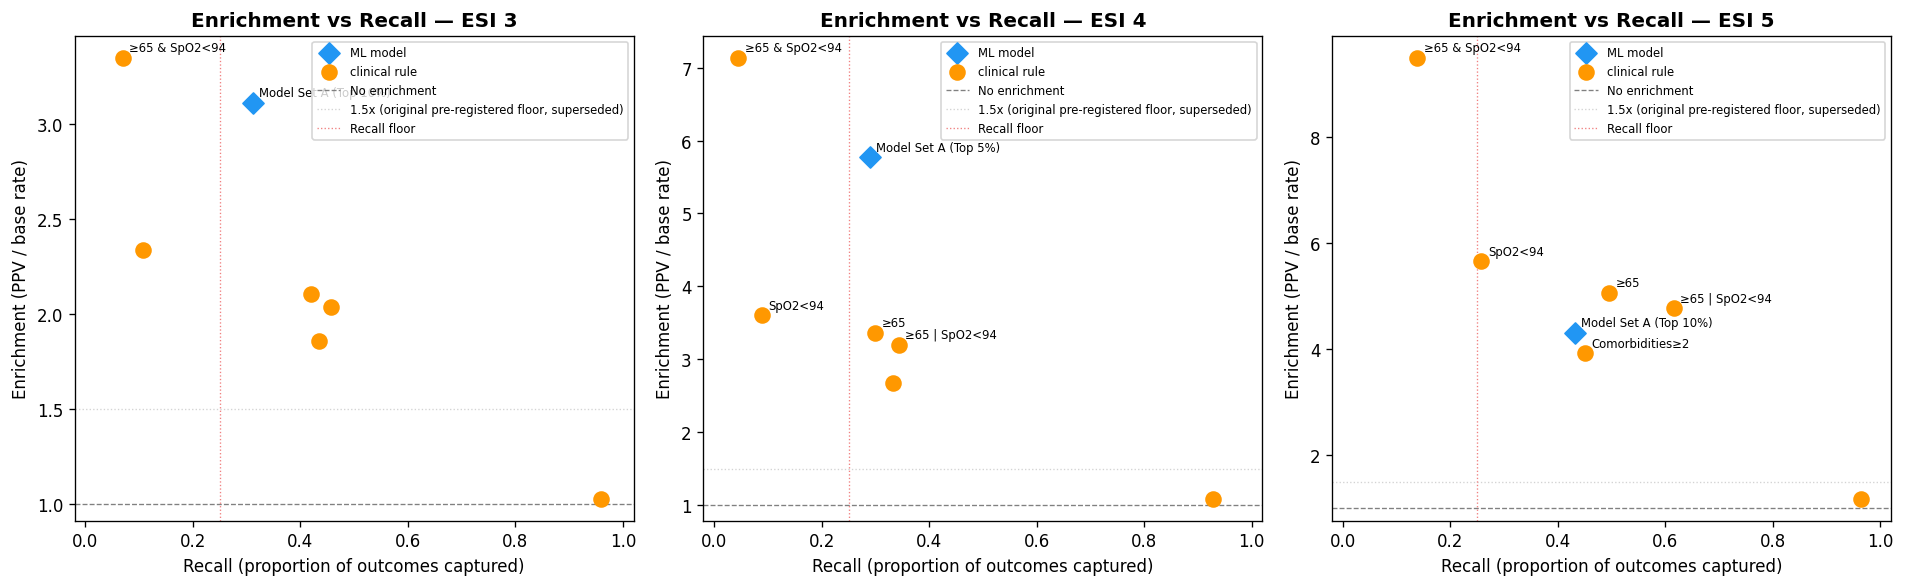

Saved: 03_model_vs_baselines_plot.png


In [8]:
# Visual comparison: enrichment vs recall for model vs baselines
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'ML model': '#2196F3', 'clinical rule': '#FF9800'}
markers = {'ML model': 'D', 'clinical rule': 'o'}

for ax, esi in zip(axes, [3, 4, 5]):
    sub = df_comp[df_comp['esi'] == esi]
    for _, r in sub.iterrows():
        c = colors[r['type']]
        m = markers[r['type']]
        ax.scatter(r['recall'], r['enrichment'], color=c, marker=m,
                   s=80, zorder=3,
                   label=r['type'] if r.name == sub[sub['type']==r['type']].index[0] else '')
        # Label only model and key baselines
        if r['type'] == 'ML model' or r['enrichment'] > 3.0:
            short = r['rule_or_model'].replace('age_65plus AND hypoxemia_flag', '≥65 & SpO2<94')\
                                      .replace('age_65plus OR hypoxemia_flag', '≥65 | SpO2<94')\
                                      .replace('age_65plus', '≥65')\
                                      .replace('hypoxemia_flag', 'SpO2<94')\
                                      .replace('comorbidity_count >= 2', 'Comorbidities≥2')\
                                      .replace('bp_not_missing', 'BP recorded')
            ax.annotate(short, (r['recall'], r['enrichment']),
                        textcoords='offset points', xytext=(4, 4), fontsize=7)

    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='No enrichment')
    ax.axhline(1.5, color='lightgray', linestyle=':', linewidth=0.8, label='1.5x (original pre-registered floor, superseded)')
    ax.axvline(0.25, color='lightcoral', linestyle=':', linewidth=0.8, label='Recall floor')
    ax.set_title(f'Enrichment vs Recall — ESI {esi}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall (proportion of outcomes captured)')
    ax.set_ylabel('Enrichment (PPV / base rate)')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(REPORT_DIR / '03_model_vs_baselines_plot.png', bbox_inches='tight')
plt.show()
print('Saved: 03_model_vs_baselines_plot.png')


---
## Section 5 — Calibration

A clinical alert that says 'elevated risk' should produce probabilities that correspond to observed outcome rates. A score of 0.30 should predict hospitalization approximately 30% of the time — otherwise the probability interpretation is misleading.

We report Brier score (lower is better; naive classifier = base rate² + (1-base rate)²) and a reliability diagram per ESI.

ESI 3: Brier=0.1731  Naive=0.1167  Skill=-0.483
ESI 4: Brier=0.0682  Naive=0.0243  Skill=-1.812
ESI 5: Brier=0.0346  Naive=0.0339  Skill=-0.022


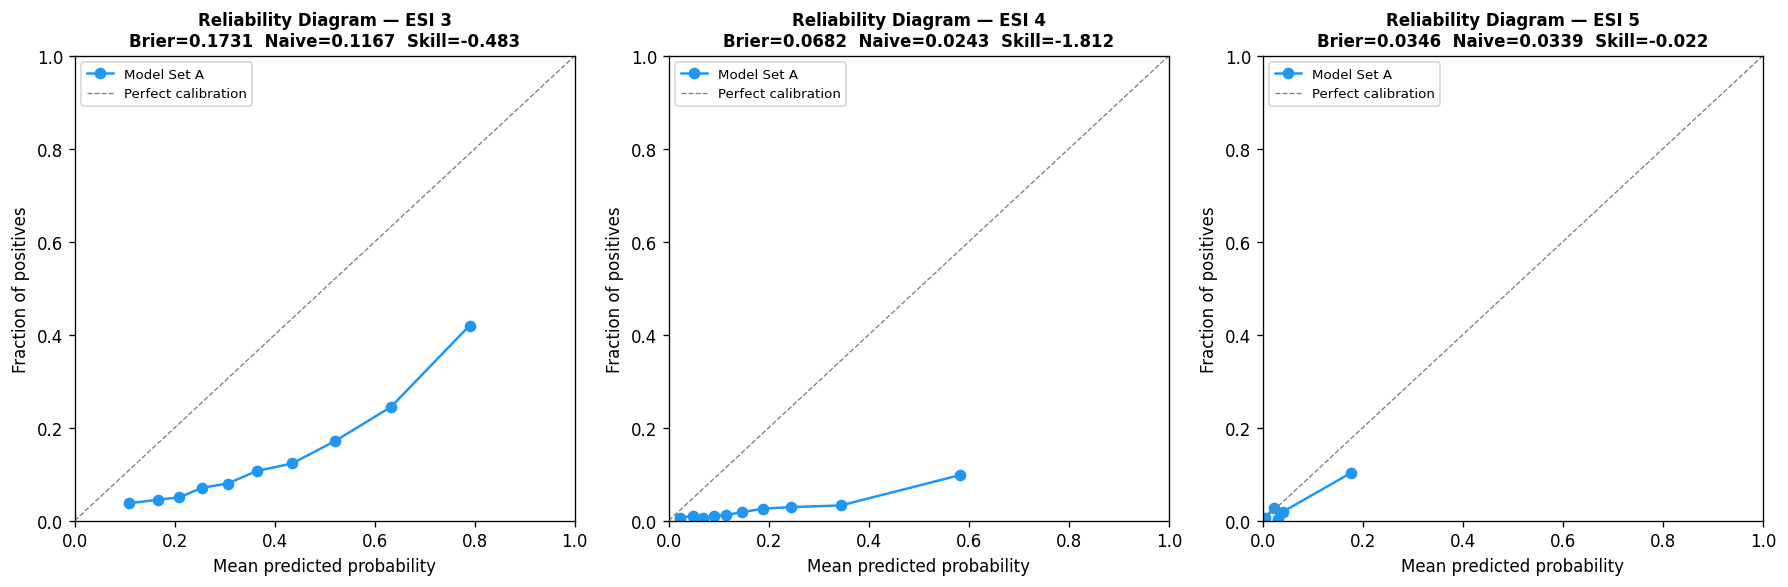


Saved: 03_calibration_plots.png, 03_calibration_metrics.json
Brier skill > 0 means model outperforms naive baseline (always predict base rate).


In [9]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

calib_metrics = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, esi in zip(axes, [3, 4, 5]):
    df_esi   = oof[esi]
    scores   = df_esi['oof_score_A'].dropna()
    y_true   = df_esi.loc[scores.index, 'outcome']
    base_rate = y_true.mean()

    # Brier score
    brier = brier_score_loss(y_true, scores)
    # Naive classifier Brier (predict base rate for all)
    brier_naive = brier_score_loss(y_true, np.full(len(y_true), base_rate))

    # Reliability diagram
    n_bins = 10 if esi < 5 else 5  # fewer bins for ESI 5 (small N)
    frac_pos, mean_pred = calibration_curve(y_true, scores, n_bins=n_bins, strategy='quantile')

    ax.plot(mean_pred, frac_pos, 'o-', color='#2196F3', label='Model Set A')
    ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=0.8, label='Perfect calibration')
    ax.set_title(f'Reliability Diagram — ESI {esi}\n'
                 f'Brier={brier:.4f}  Naive={brier_naive:.4f}  '
                 f'Skill={1 - brier/brier_naive:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    calib_metrics[esi] = {
        'esi': esi, 'brier_score': round(brier, 5),
        'brier_naive': round(brier_naive, 5),
        'brier_skill': round(1 - brier / brier_naive, 4),
        'base_rate': round(base_rate, 4),
        'n': int(len(scores)),
    }
    print(f'ESI {esi}: Brier={brier:.4f}  Naive={brier_naive:.4f}  '
          f'Skill={1-brier/brier_naive:.3f}')

plt.tight_layout()
plt.savefig(REPORT_DIR / '03_calibration_plots.png', bbox_inches='tight')
plt.show()

with open(REPORT_DIR / '03_calibration_metrics.json', 'w') as f:
    json.dump(calib_metrics, f, indent=2)
print('\nSaved: 03_calibration_plots.png, 03_calibration_metrics.json')
print('Brier skill > 0 means model outperforms naive baseline (always predict base rate).')


---
## Section 6 — Threshold Sweep Curves

Visual summary of the PPV–recall–burden trade-off across thresholds. Vertical line marks the chosen threshold. The 25% recall floor is marked for reference.

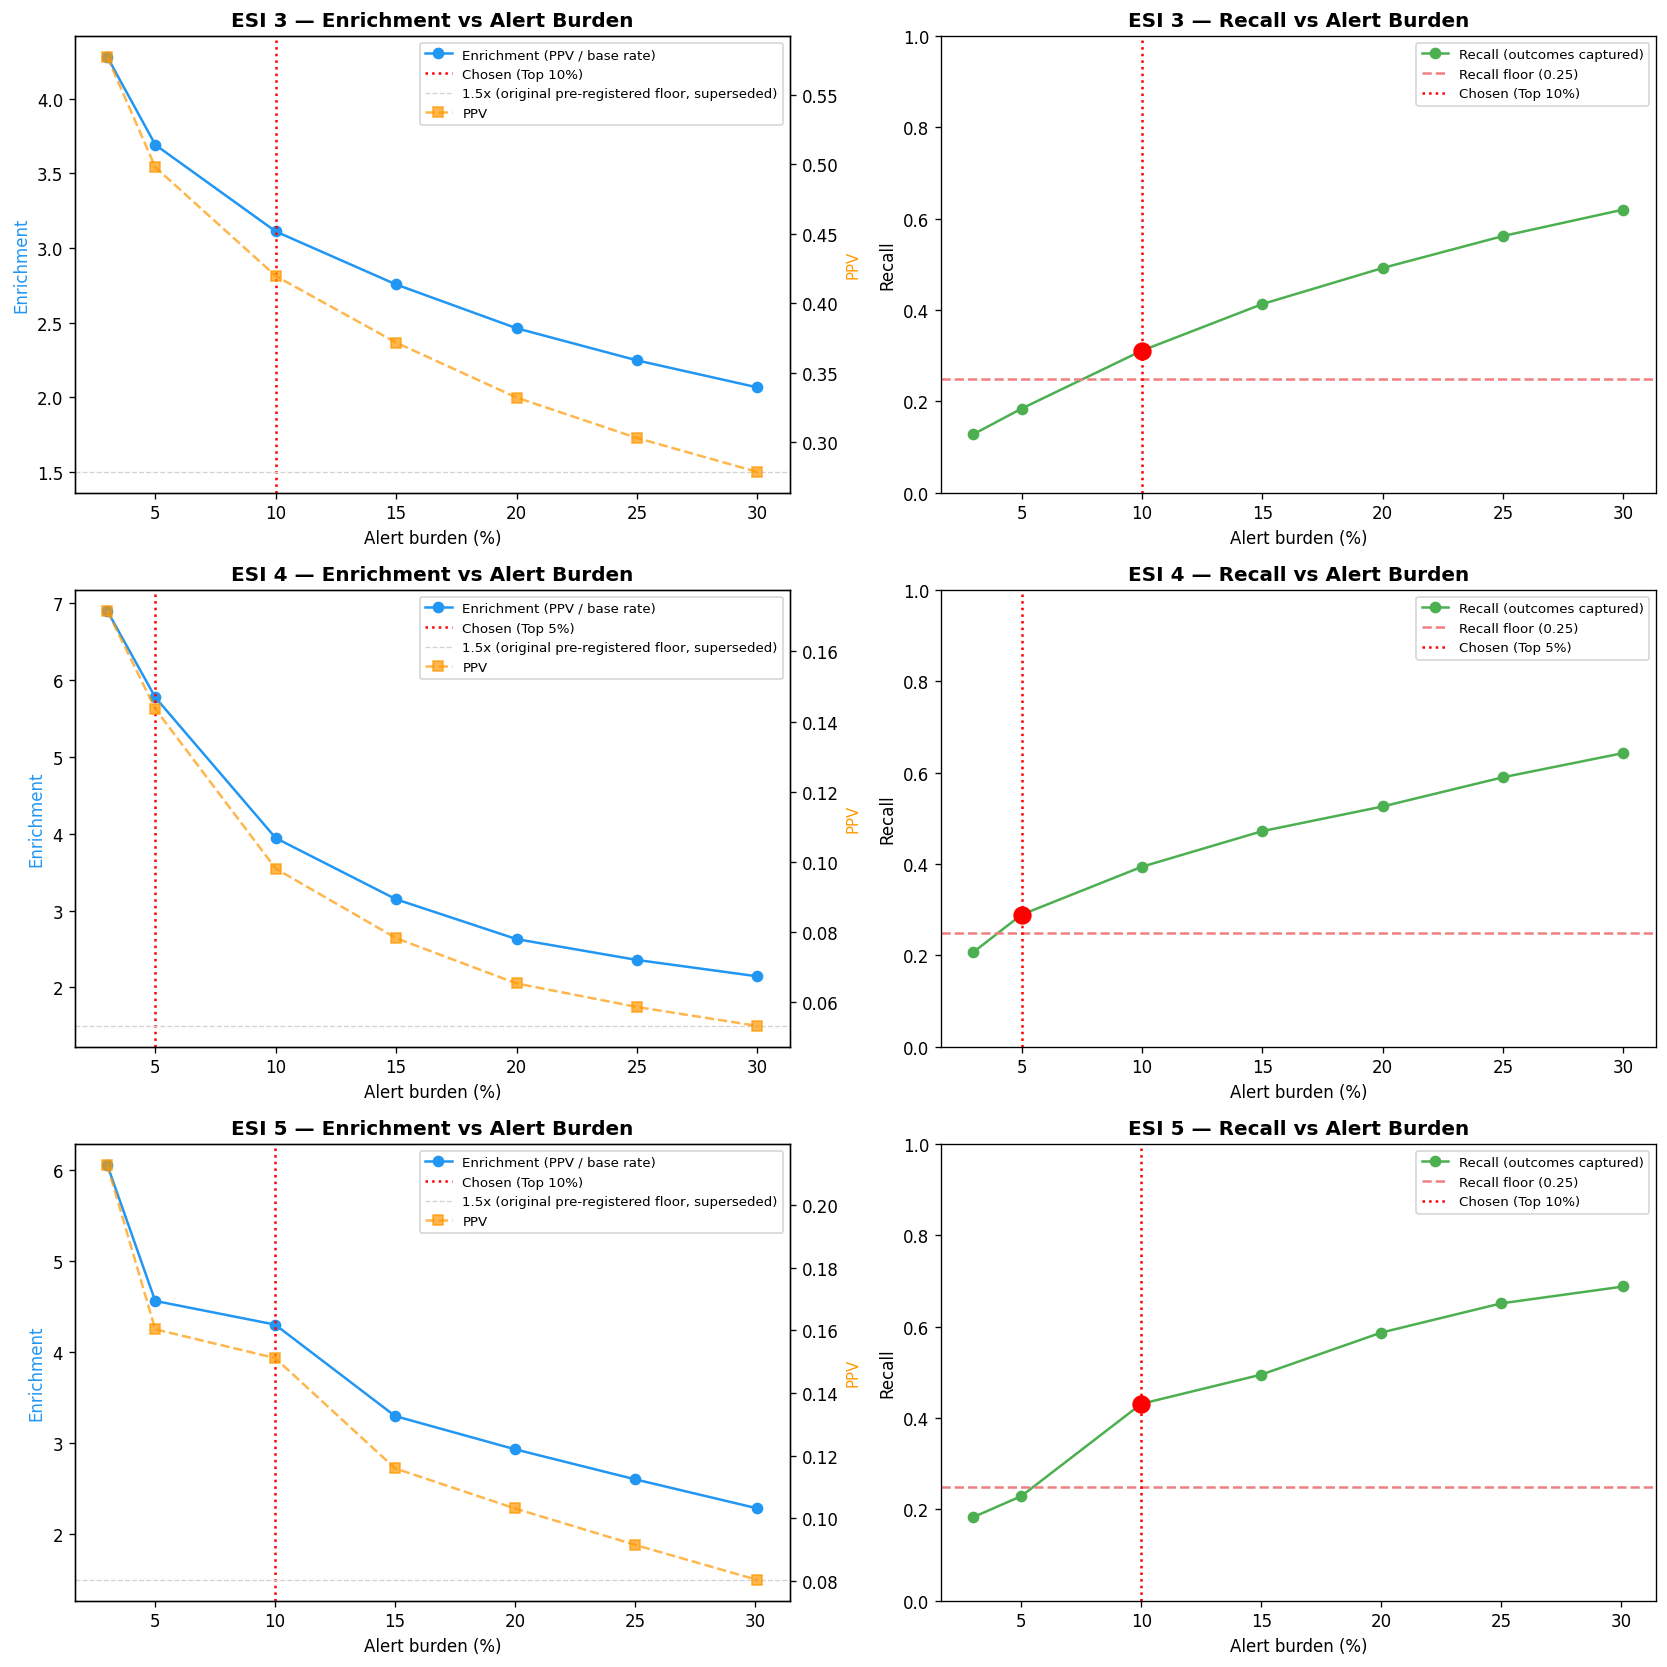

Saved: 03_threshold_sweep_curves.png


In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for row_i, esi in enumerate([3, 4, 5]):
    sub = df_sweep[df_sweep['esi'] == esi].sort_values('threshold_pct')
    chosen_pct = final_policy[esi].get('threshold_pct')

    # Left: Enrichment and PPV vs burden
    ax = axes[row_i, 0]
    ax.plot(sub['alert_burden_pct'], sub['enrichment'], 'o-',
            color='#2196F3', label='Enrichment (PPV / base rate)')
    ax2 = ax.twinx()
    ax2.plot(sub['alert_burden_pct'], sub['ppv'], 's--',
             color='#FF9800', label='PPV', alpha=0.7)
    ax2.set_ylabel('PPV', color='#FF9800', fontsize=9)
    if chosen_pct:
        ch = sub[sub['threshold_pct'] == chosen_pct].iloc[0]
        ax.axvline(ch['alert_burden_pct'], color='red', linestyle=':', linewidth=1.5,
                   label=f'Chosen (Top {chosen_pct}%)')
    ax.axhline(1.5, color='lightgray', linestyle='--', linewidth=0.8, label='1.5x (original pre-registered floor, superseded)')
    ax.set_title(f'ESI {esi} — Enrichment vs Alert Burden', fontweight='bold')
    ax.set_xlabel('Alert burden (%)')
    ax.set_ylabel('Enrichment', color='#2196F3')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

    # Right: Recall vs burden
    ax = axes[row_i, 1]
    ax.plot(sub['alert_burden_pct'], sub['recall'], 'o-',
            color='#4CAF50', label='Recall (outcomes captured)')
    ax.axhline(0.25, color='lightcoral', linestyle='--', linewidth=1.5,
               label='Recall floor (0.25)')
    if chosen_pct:
        ch = sub[sub['threshold_pct'] == chosen_pct].iloc[0]
        ax.axvline(ch['alert_burden_pct'], color='red', linestyle=':', linewidth=1.5,
                   label=f'Chosen (Top {chosen_pct}%)')
        ax.scatter([ch['alert_burden_pct']], [ch['recall']],
                   color='red', s=100, zorder=5)
    ax.set_title(f'ESI {esi} — Recall vs Alert Burden', fontweight='bold')
    ax.set_xlabel('Alert burden (%)')
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORT_DIR / '03_threshold_sweep_curves.png', bbox_inches='tight')
plt.show()
print('Saved: 03_threshold_sweep_curves.png')


---
## Section 7 — Hypothetical Operational Simulation

> **Important methodological note:** NHAMCS is a national probability sample with visit weights (PATWT), not a continuous log of a real hospital. The per-shift figures below are purely illustrative — they depend entirely on the actual patient volume of a specific service. Alert burden as a percentage is the primary operational metric.

In [11]:
print('=== ALERT BURDEN SUMMARY — PRIMARY METRIC ===')
print('(Alert burden as % of ESI patients — service-volume independent)\n')

burden_rows = []
for esi in [3, 4, 5]:
    p = final_policy[esi]
    if p['status'] != 'active':
        print(f'ESI {esi}: EXPLORATORY — no active policy')
        continue
    n_total = len(oof[esi])
    alerts_per_1000 = round(p['alert_burden_pct'] * 10, 1)
    print(f'ESI {esi} | Top {p["threshold_pct"]}% threshold')
    print(f'  Alert burden:       {p["alert_burden_pct"]:.1f}% of ESI patients')
    print(f'  Per 1,000 ESI-specific visits: {alerts_per_1000:.0f} alerts')
    print(f'  PPV:                {p["ppv"]:.3f}  '
          f'(1 in {int(1/p["ppv"])} alerts is a true positive)')
    print(f'  Outcomes captured:  {p["n_outcomes_captured"]} of '
          f'{p["n_outcomes_total"]} ({p["recall"]*100:.1f}%)')
    burden_rows.append({'esi': esi, 'threshold_pct': p['threshold_pct'],
                        'burden_pct': p['alert_burden_pct'],
                        'alerts_per_1000': alerts_per_1000,
                        'ppv': p['ppv'], 'enrichment': p['enrichment'],
                        'recall': p['recall']})
    print()

print('--- Hypothetical operational example (illustrative only) ---')
for r in burden_rows:
    esi = r['esi']
    pct = r['burden_pct']
    for vol in [30, 50, 100]:
        n_alerts = round(vol * pct / 100, 1)
        print(f'  ESI {esi} | {vol} patients/shift → ~{n_alerts:.0f} alerts/shift '
              f'(Top {r["threshold_pct"]}% policy)')
    print()


=== ALERT BURDEN SUMMARY — PRIMARY METRIC ===
(Alert burden as % of ESI patients — service-volume independent)

ESI 3 | Top 10% threshold
  Alert burden:       10.0% of ESI patients
  Per 1,000 ESI-specific visits: 100 alerts
  PPV:                0.420  (1 in 2 alerts is a true positive)
  Outcomes captured:  1320 of 4244 (31.1%)

ESI 4 | Top 5% threshold
  Alert burden:       5.0% of ESI patients
  Per 1,000 ESI-specific visits: 50 alerts
  PPV:                0.144  (1 in 6 alerts is a true positive)
  Outcomes captured:  145 of 502 (28.9%)

ESI 5 | Top 10% threshold
  Alert burden:       10.0% of ESI patients
  Per 1,000 ESI-specific visits: 100 alerts
  PPV:                0.151  (1 in 6 alerts is a true positive)
  Outcomes captured:  47 of 109 (43.1%)

--- Hypothetical operational example (illustrative only) ---
  ESI 3 | 30 patients/shift → ~3 alerts/shift (Top 10% policy)
  ESI 3 | 50 patients/shift → ~5 alerts/shift (Top 10% policy)
  ESI 3 | 100 patients/shift → ~10 alerts/s

---
## Section 8 — Output Artifacts

In [12]:
import os
print('=== ARTIFACTS SAVED IN reports/03_alert_policy/ ===')
for f in sorted(REPORT_DIR.iterdir()):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f.name:<45}  {size_kb:>8.1f} KB')

# Print final policy one last time for the record
print()
print('=== FINAL POLICY (from 03_final_policy.json) ===')
with open(REPORT_DIR / '03_final_policy.json') as f:
    print(json.dumps(json.load(f), indent=2))


=== ARTIFACTS SAVED IN reports/03_alert_policy/ ===
  03_calibration_metrics.json                         0.5 KB
  03_calibration_plots.png                           60.0 KB
  03_final_policy.json                                1.4 KB
  03_model_vs_baselines.csv                           1.6 KB
  03_model_vs_baselines_plot.png                     71.8 KB
  03_policy_with_ci.csv                               0.8 KB
  03_threshold_sweep_by_esi.csv                       1.3 KB
  03_threshold_sweep_curves.png                     240.5 KB

=== FINAL POLICY (from 03_final_policy.json) ===
{
  "3": {
    "esi": 3,
    "status": "active",
    "threshold_pct": 10,
    "score_cutoff": 0.6991,
    "alert_burden_pct": 10.0,
    "ppv": 0.4196,
    "base_rate": 0.1349,
    "enrichment": 3.11,
    "recall": 0.311,
    "n_alerted": 3146,
    "n_outcomes_captured": 1320,
    "n_outcomes_total": 4244,
    "ppv_ci_lo": 0.402,
    "ppv_ci_hi": 0.4369,
    "enrichment_ci_lo": 3.002,
    "enrichment_ci_hi":